In [5]:
# ── Hardcoded reference energies (from previous run — kernel died) ─────────────
E_mof_T = {
    300:  -1170.927377,
    350:  -1169.929831,
    400:  -1168.871917,
    450:  -1167.828917,
    500:  -1167.054063,
    550:  -1166.128098,
    600:  -1165.371719,
    650:  -1164.211804,
    700:  -1163.518253,
    750:  -1162.268107,
    800:  -1161.478469,
    850:  -1160.795954,
    900:  -1160.017901,
    950:  -1158.307032,
    1000: -1157.488400,
}

E_co2_T = {
    300:  -22.522742,
    350:  -22.562976,
    400:  -22.524729,
    450:  -22.505545,
    500:  -22.508393,
    550:  -22.529646,
    600:  -22.446196,
    650:  -22.517010,
    700:  -22.488526,
    750:  -22.476538,
    800:  -22.561484,
    850:  -22.502157,
    900:  -22.446900,
    950:  -22.381456,
    1000: -22.426128,
}

E_mof  = E_mof_T[300]
E_co2  = E_co2_T[300]

print("Reference energies loaded from hardcoded values.")

Reference energies loaded from hardcoded values.


Found 15 trajectory files:
  300 K → /Users/christopherli/Documents/2026_Spring/cbe423/final-project/cbe423-final_project/trajectories_gui_corrected/md_sitegui_300K_20260420_143719.traj
  350 K → /Users/christopherli/Documents/2026_Spring/cbe423/final-project/cbe423-final_project/trajectories_gui_corrected/md_sitegui_350K_20260420_175307.traj
  400 K → /Users/christopherli/Documents/2026_Spring/cbe423/final-project/cbe423-final_project/trajectories_gui_corrected/md_sitegui_400K_20260420_210225.traj
  450 K → /Users/christopherli/Documents/2026_Spring/cbe423/final-project/cbe423-final_project/trajectories_gui_corrected/md_sitegui_450K_20260421_001946.traj
  500 K → /Users/christopherli/Documents/2026_Spring/cbe423/final-project/cbe423-final_project/trajectories_gui_corrected/md_sitegui_500K_20260421_033726.traj
  550 K → /Users/christopherli/Documents/2026_Spring/cbe423/final-project/cbe423-final_project/trajectories_gui_corrected/md_sitegui_550K_20260421_065122.traj
  600 K → /Users/ch

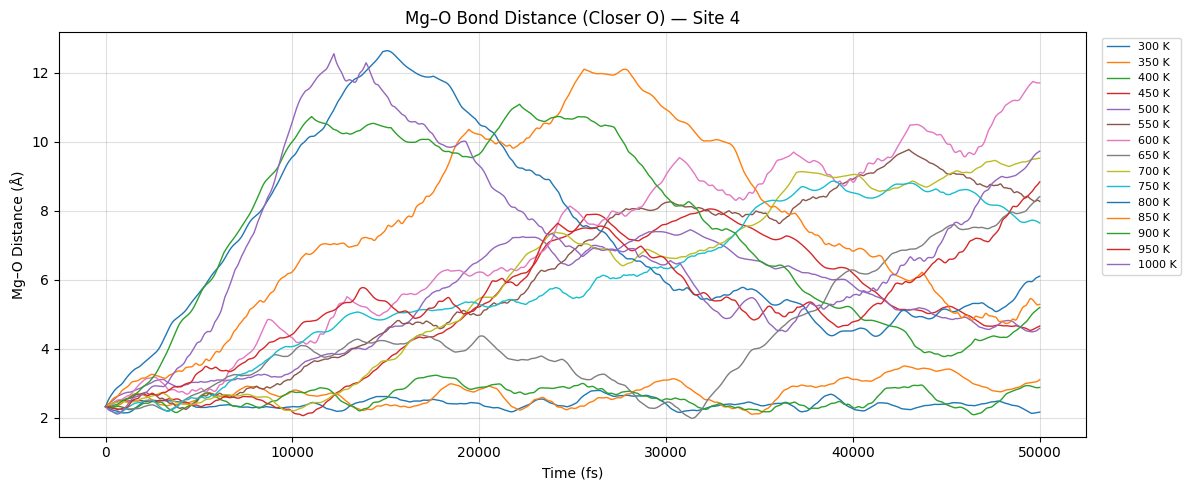

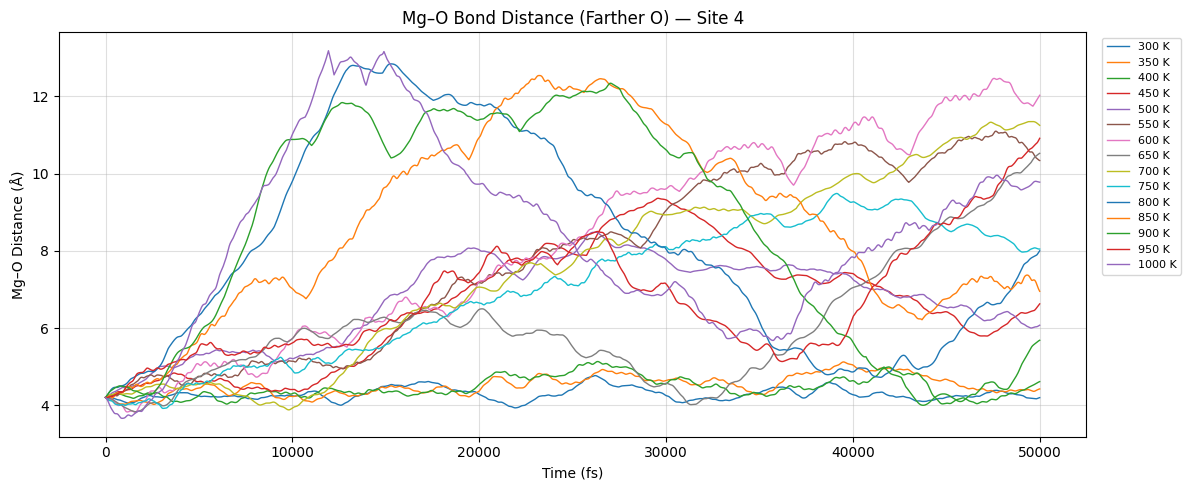

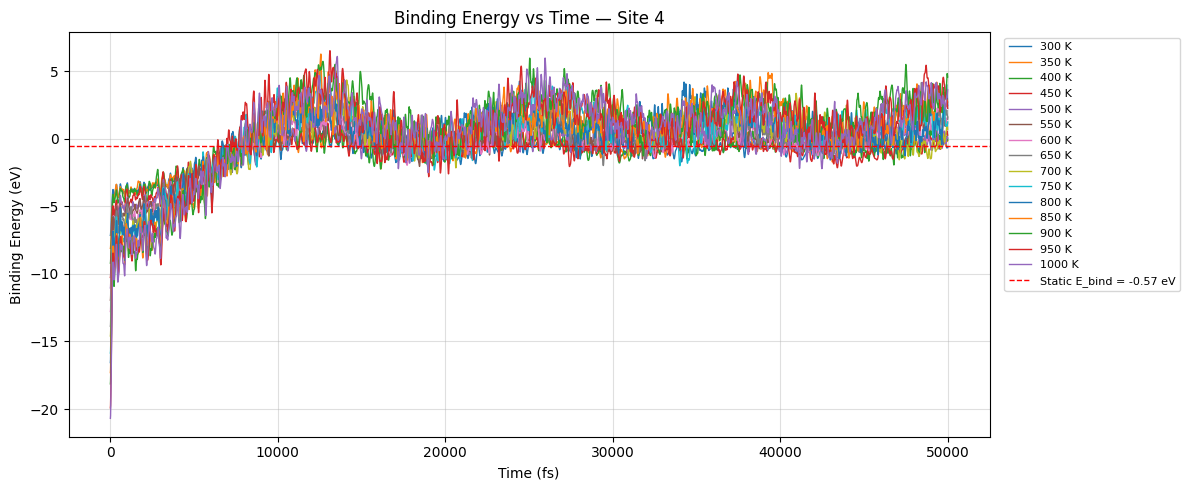

/var/folders/_z/4q19dfw93z98h599v771k7wr0000gn/T/ipykernel_33218/834971316.py:140: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(fontsize=8)


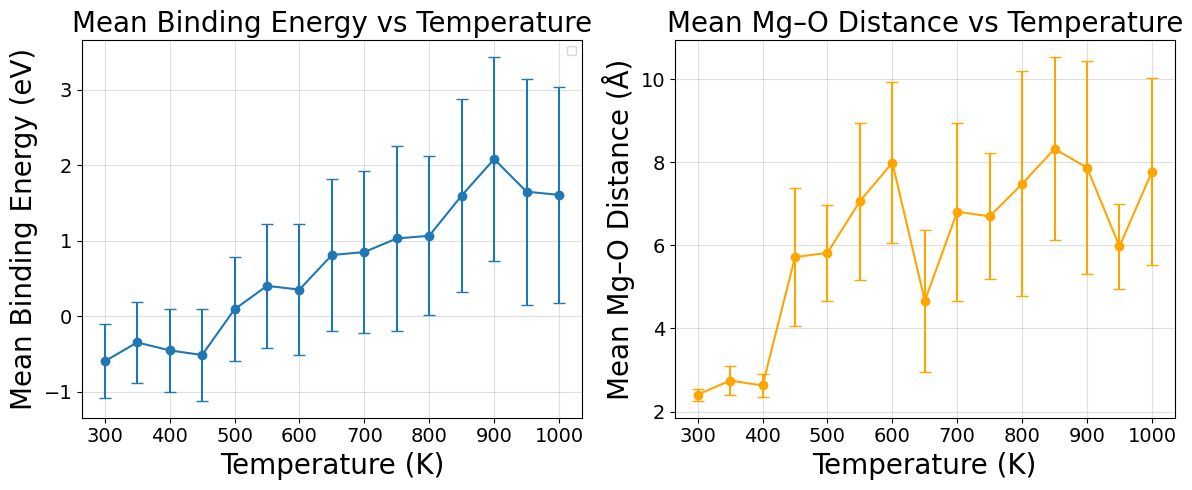


T (K)    <E_bind> (eV)      std        <Mg-O> (Å)      std       
------------------------------------------------------------
300      -0.5979            0.4889     2.405           0.141     
350      -0.3473            0.5410     2.744           0.357     
400      -0.4530            0.5514     2.628           0.282     
450      -0.5141            0.6036     5.717           1.657     
500      0.0912             0.6888     5.819           1.150     
550      0.4018             0.8190     7.061           1.891     
600      0.3520             0.8649     7.989           1.943     
650      0.8104             1.0096     4.663           1.707     
700      0.8493             1.0730     6.809           2.141     
750      1.0295             1.2242     6.696           1.516     
800      1.0651             1.0541     7.478           2.709     
850      1.5970             1.2764     8.321           2.199     
900      2.0811             1.3456     7.868           2.562     
950      1.649

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ase.io.trajectory import Trajectory
import glob
import re
from datetime import datetime

# -------------------------------------------------------
# CONFIG — edit these
# -------------------------------------------------------
TRAJ_FOLDER  = "/Users/christopherli/Documents/2026_Spring/cbe423/final-project/cbe423-final_project/trajectories_gui_corrected"   # folder containing your .traj files
MG_IDX       = 4                     # Mg site atom index
TIMESTEP_FS  = 1.0                   # MD timestep in fs
TRAJ_EVERY   = 10                    # interval used when writing frames
E_MOF        = -1177.415309              # replace with your E_mof value (eV)
E_CO2        = -22.596883              # replace with your E_co2 value (eV)
# -------------------------------------------------------

# Find and sort all trajectory files by temperature
traj_files = glob.glob(f"{TRAJ_FOLDER}/md_sitegui_*K_*.traj")

def extract_temp(fname):
    match = re.search(r'_(\d+)K_', fname)
    return int(match.group(1)) if match else 0

traj_files = sorted(traj_files, key=extract_temp)
temperatures = [extract_temp(f) for f in traj_files]

print(f"Found {len(traj_files)} trajectory files:")
for T, f in zip(temperatures, traj_files):
    print(f"  {T} K → {f}")

# -------------------------------------------------------
# Extract data from each trajectory
# -------------------------------------------------------
data = {}

for T, fpath in zip(temperatures, traj_files):
    traj = Trajectory(fpath, "r")

    times   = []
    mg_o_d1 = []
    mg_o_d2 = []
    e_bind  = []

    for i, atoms in enumerate(traj):
        time_fs = i * TIMESTEP_FS * TRAJ_EVERY

        # Mg-O distances (CO2 is last 3 atoms)
        co2_start = len(atoms) - 3
        o_indices = [j for j in range(co2_start, len(atoms)) if atoms[j].symbol == "O"]
        dists = sorted([atoms.get_distance(MG_IDX, o_idx, mic=True) for o_idx in o_indices])

        times.append(time_fs)
        mg_o_d1.append(dists[0])
        mg_o_d2.append(dists[1])
        e_bind.append(atoms.get_potential_energy() - E_mof_T[T] - E_co2_T[T])

    data[T] = {
        "times":   np.array(times),
        "mg_o_d1": np.array(mg_o_d1),
        "mg_o_d2": np.array(mg_o_d2),
        "e_bind":  np.array(e_bind),
    }
    print(f"  {T} K: {len(times)} frames loaded")

# -------------------------------------------------------
# Plot 1 — Mg-O bond distance (closer O) vs time
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5))
for T, d in data.items():
    ax.plot(d["times"], d["mg_o_d1"], lw=1.0, label=f"{T} K")
ax.set_xlabel("Time (fs)")
ax.set_ylabel("Mg–O Distance (Å)")
ax.set_title(f"Mg–O Bond Distance (Closer O) — Site {MG_IDX}")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f"comparison_mg_o_closer_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png", dpi=150, bbox_inches="tight")
plt.show()

# -------------------------------------------------------
# Plot 2 — Mg-O bond distance (farther O) vs time
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5))
for T, d in data.items():
    ax.plot(d["times"], d["mg_o_d2"], lw=1.0, label=f"{T} K")
ax.set_xlabel("Time (fs)")
ax.set_ylabel("Mg–O Distance (Å)")
ax.set_title(f"Mg–O Bond Distance (Farther O) — Site {MG_IDX}")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f"comparison_mg_o_farther_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png", dpi=150, bbox_inches="tight")
plt.show()

# -------------------------------------------------------
# Plot 3 — Binding energy vs time
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5))
for T, d in data.items():
    ax.plot(d["times"], d["e_bind"], lw=1.0, label=f"{T} K")
ax.axhline(-0.57, color="red", ls="--", lw=1, label="Static E_bind = -0.57 eV")
ax.set_xlabel("Time (fs)")
ax.set_ylabel("Binding Energy (eV)")
ax.set_title(f"Binding Energy vs Time — Site {MG_IDX}")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f"comparison_binding_energy_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png", dpi=150, bbox_inches="tight")
plt.show()

# -------------------------------------------------------
# Plot 4 — Mean binding energy vs temperature (summary)
# -------------------------------------------------------
eq_cut_frac = 0.2  # discard first 20% as equilibration

mean_e_bind = []
std_e_bind  = []
mean_mg_o   = []
std_mg_o    = []

for T in sorted(data.keys()):
    d      = data[T]
    eq_cut = int(len(d["times"]) * eq_cut_frac)
    mean_e_bind.append(d["e_bind"][eq_cut:].mean())
    std_e_bind.append(d["e_bind"][eq_cut:].std())
    mean_mg_o.append(d["mg_o_d1"][eq_cut:].mean())
    std_mg_o.append(d["mg_o_d1"][eq_cut:].std())

sorted_temps = sorted(data.keys())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.errorbar(sorted_temps, mean_e_bind, yerr=std_e_bind, fmt="o-", capsize=4)
#ax1.axhline(-0.57, color="red", ls="--", lw=1, label="Static E_bind = -0.57 eV")
ax1.set_xlabel("Temperature (K)", fontsize=20)
ax1.set_ylabel("Mean Binding Energy (eV)", fontsize=20)
#ax1.set_title("Mean Binding Energy vs Temperature", fontsize=20)
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.4)
ax1.tick_params(axis='both', labelsize=14)

ax2.errorbar(sorted_temps, mean_mg_o, yerr=std_mg_o, fmt="o-", capsize=4, color="orange")
ax2.set_xlabel("Temperature (K)", fontsize=20)
ax2.set_ylabel("Mean Mg–O Distance (Å)", fontsize=20)
#ax2.set_title("Mean Mg–O Distance vs Temperature", fontsize=20)
ax2.grid(True, alpha=0.4)
ax2.tick_params(axis='both', labelsize=14)

plt.tight_layout()
#plt.savefig(f"comparison_summary_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png", dpi=150, bbox_inches="tight")
plt.show()

# -------------------------------------------------------
# Print summary table
# -------------------------------------------------------
print(f"\n{'T (K)':<8} {'<E_bind> (eV)':<18} {'std':<10} {'<Mg-O> (Å)':<15} {'std':<10}")
print("-" * 60)
for T, me, se, md, sd in zip(sorted_temps, mean_e_bind, std_e_bind, mean_mg_o, std_mg_o):
    print(f"{T:<8} {me:<18.4f} {se:<10.4f} {md:<15.3f} {sd:<10.3f}")

  350 K: 5001 frames loaded
  500 K: 5001 frames loaded
  750 K: 5001 frames loaded
  1000 K: 5001 frames loaded


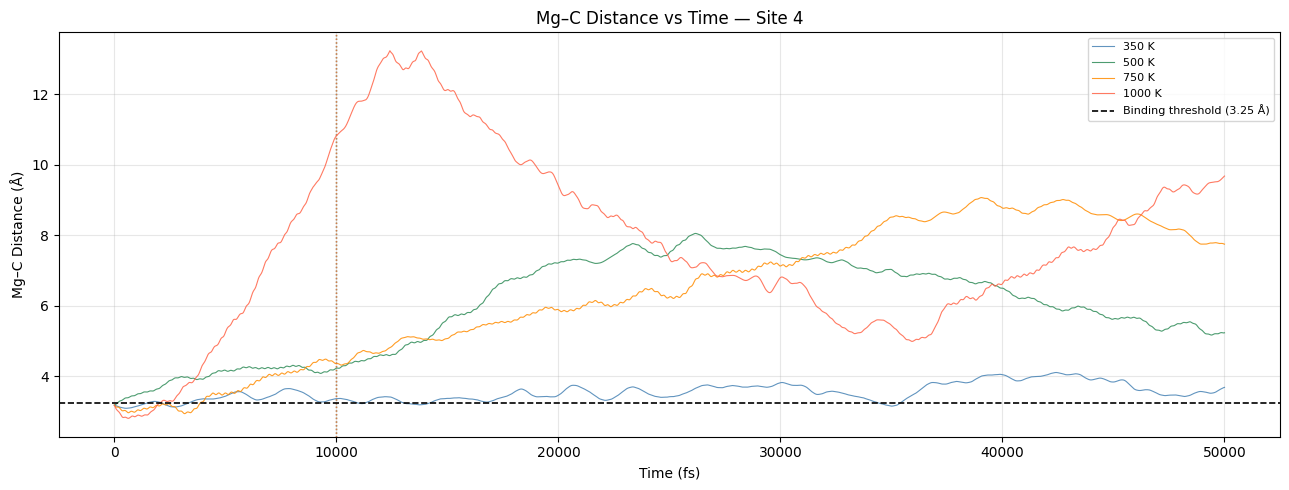

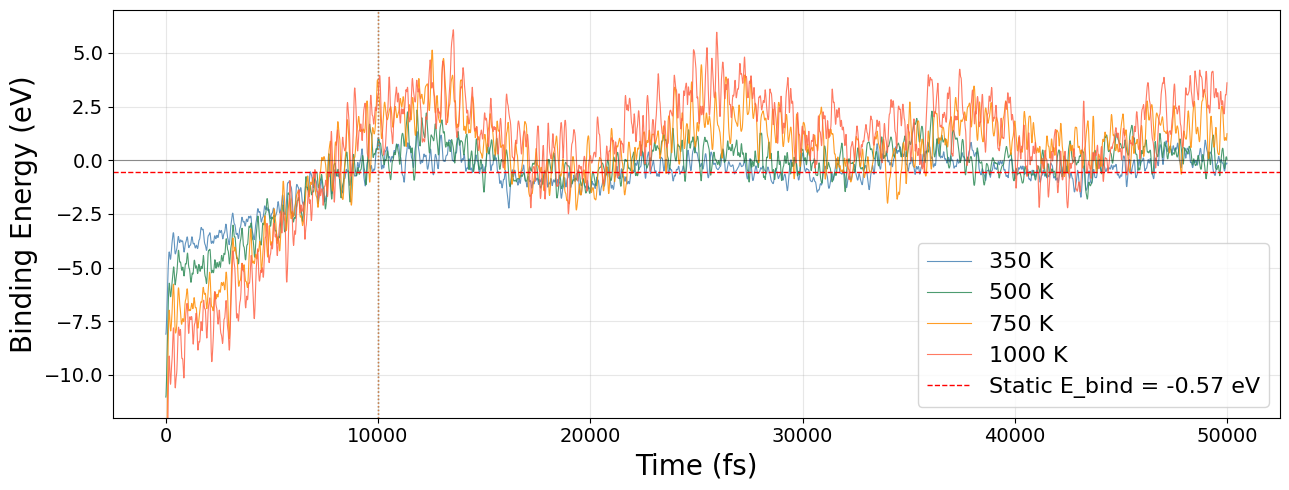

In [59]:
# -------------------------------------------------------
# Plot A — Mg–C distance vs time for selected temperatures
# -------------------------------------------------------
EQ_CUT_FRAC         = 0.20
BINDING_THRESHOLD_A = 3.25

TARGET_TEMPS = [350, 500, 750, 1000]
colors       = {350: "steelblue", 500: "seagreen", 750: "darkorange", 1000: "tomato"}

# ── collect data ──
traj_data = {}
for T in TARGET_TEMPS:
    if T not in temperatures:
        print(f"  {T} K not found")
        continue

    fpath = traj_files[temperatures.index(T)]
    traj  = Trajectory(fpath, "r")

    times      = []
    mg_c_dists = []
    e_bind     = []

    for i, atoms in enumerate(traj):
        time_fs   = i * TIMESTEP_FS * TRAJ_EVERY
        co2_start = len(atoms) - 3
        c_indices = [j for j in range(co2_start, len(atoms)) if atoms[j].symbol == "C"]
        if not c_indices:
            continue
        dist = atoms.get_distance(MG_IDX, c_indices[0], mic=True)
        times.append(time_fs)
        mg_c_dists.append(dist)
        e_bind.append(atoms.get_potential_energy() - E_mof_T[T] - E_co2_T[T])

    traj_data[T] = {
        "times":      np.array(times),
        "mg_c_dists": np.array(mg_c_dists),
        "e_bind":     np.array(e_bind),
        "eq_cut_fs":  np.array(times)[int(len(times) * EQ_CUT_FRAC)],
    }
    print(f"  {T} K: {len(times)} frames loaded")

# ── Plot A: Mg–C distance ──
fig, ax = plt.subplots(figsize=(13, 5))
for T, d in traj_data.items():
    ax.plot(d["times"], d["mg_c_dists"], lw=0.8, color=colors[T], label=f"{T} K", alpha=0.85)
    ax.axvline(d["eq_cut_fs"], color=colors[T], ls=":", lw=1.0, alpha=0.5)

ax.axhline(BINDING_THRESHOLD_A, color="black", ls="--", lw=1.2,
           label=f"Binding threshold ({BINDING_THRESHOLD_A} Å)")
ax.set_xlabel("Time (fs)")
ax.set_ylabel("Mg–C Distance (Å)")
ax.set_title(f"Mg–C Distance vs Time — Site {MG_IDX}")
ax.legend(fontsize=8, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig(f"mg_c_distance_selected_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png",
#             dpi=150, bbox_inches="tight")
plt.show()

# ── Plot B: Binding energy ──
fig, ax = plt.subplots(figsize=(13, 5))
for T, d in traj_data.items():
    ax.plot(d["times"], d["e_bind"], lw=0.8, color=colors[T], label=f"{T} K", alpha=0.85)
    ax.axvline(d["eq_cut_fs"], color=colors[T], ls=":", lw=1.0, alpha=0.5)
    
ax.tick_params(axis='both', labelsize=14)
ax.axhline(0,     color="black", ls="-",  lw=0.8, alpha=0.4)
ax.axhline(-0.57, color="red",   ls="--", lw=1.0, label="Static E_bind = -0.57 eV")
ax.set_xlabel("Time (fs)", fontsize=20)
ax.set_ylabel("Binding Energy (eV)", fontsize=20)
#ax.set_title(f"Binding Energy vs Time — Site {MG_IDX}")
ax.legend(fontsize=16, loc="lower right")
#ax.legend(fontsize=8, loc="lower right")
ax.grid(True, alpha=0.3)
ax.set_ylim(-12,7)
plt.tight_layout()
#plt.savefig(f"ebind_selected_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png",
            #dpi=150, bbox_inches="tight")
plt.show()

  300 K: 5001 C positions collected
  650 K: 5001 C positions collected
  950 K: 5001 C positions collected


/var/folders/_z/4q19dfw93z98h599v771k7wr0000gn/T/ipykernel_33218/766408142.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


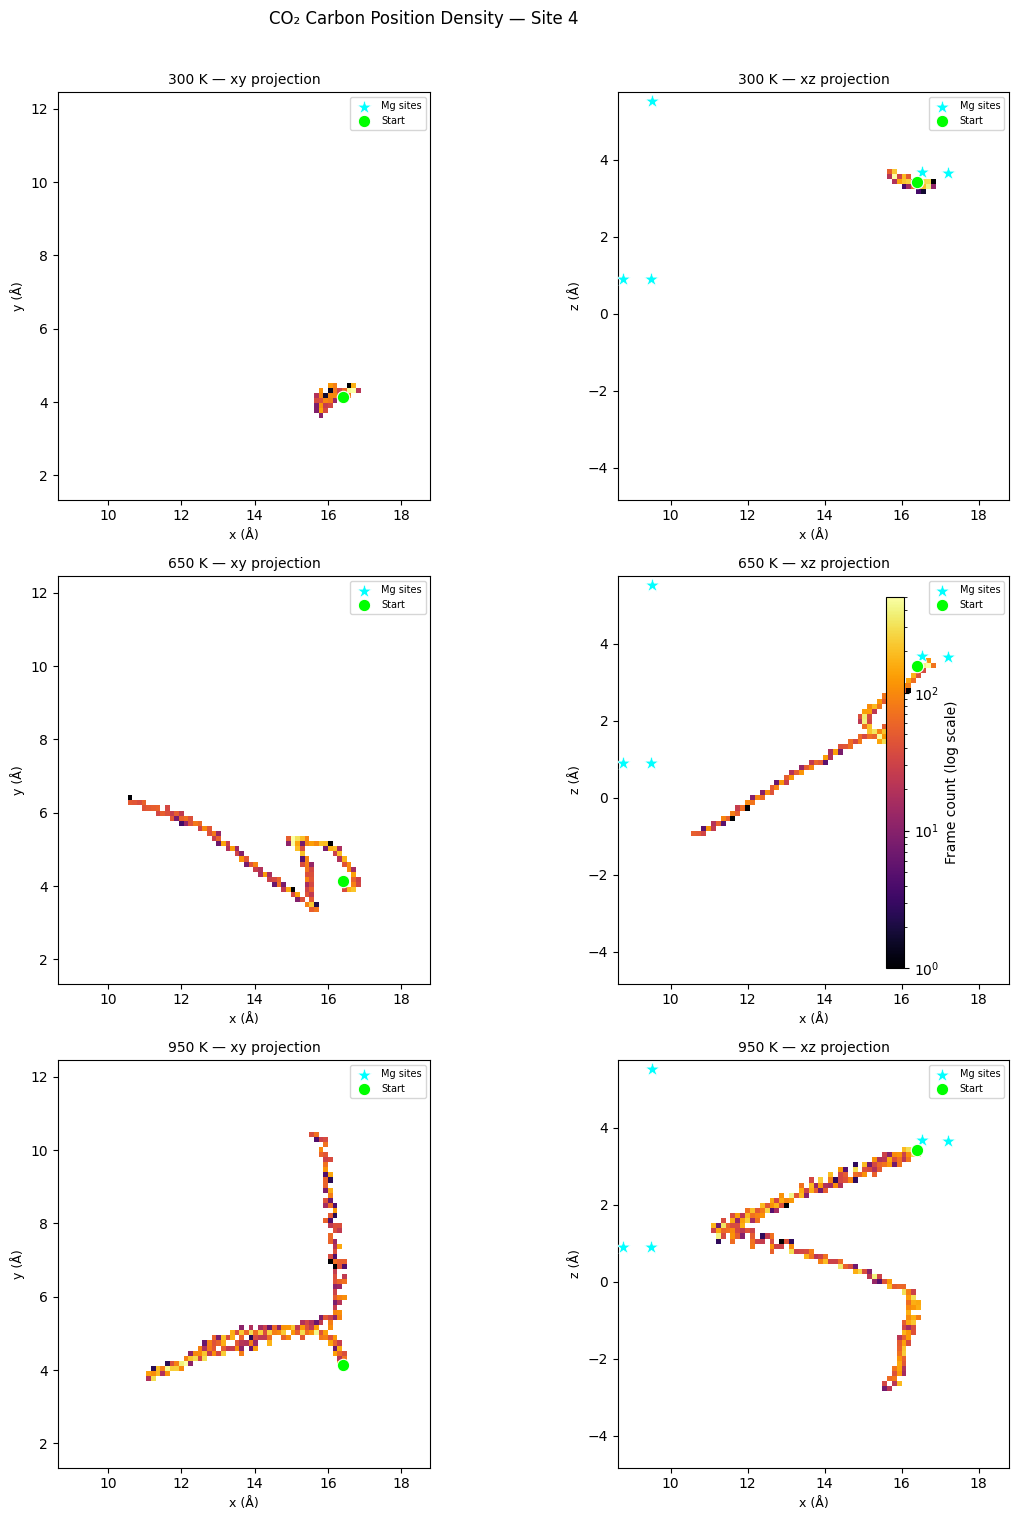

In [ ]:
# -------------------------------------------------------
# Plot — 2D density heatmap of CO₂ carbon positions
#         projected onto xy and xz planes
#         for 300 K, 650 K, and 950 K
# -------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from ase.io.trajectory import Trajectory

HEATMAP_TEMPS = [300, 650, 1000]

# ── collect C positions and Mg positions from first trajectory ──
mg_positions = None
c_positions  = {}

for T in HEATMAP_TEMPS:
    if T not in temperatures:
        print(f"  {T} K not found")
        continue

    fpath = traj_files[temperatures.index(T)]
    traj  = Trajectory(fpath, "r")

    c_pos = []
    for i, atoms in enumerate(traj):
        # grab Mg positions once from first frame of first trajectory
        if mg_positions is None:
            mg_positions = np.array([
                atoms[j].position for j in range(len(atoms))
                if atoms[j].symbol == "Mg"
            ])

        co2_start = len(atoms) - 3
        c_indices = [j for j in range(co2_start, len(atoms)) if atoms[j].symbol == "C"]
        if not c_indices:
            continue
        c_pos.append(atoms[c_indices[0]].position.copy())

    c_positions[T] = np.array(c_pos)
    print(f"  {T} K: {len(c_pos)} C positions collected")

# ── determine global axis limits from all positions ──
all_c = np.vstack(list(c_positions.values()))
x_min, x_max = all_c[:, 0].min(), all_c[:, 0].max()
y_min, y_max = all_c[:, 1].min(), all_c[:, 1].max()
z_min, z_max = all_c[:, 2].min(), all_c[:, 2].max()

# pad slightly
pad = 2.0
xlim = (x_min - pad, x_max + pad)
ylim = (y_min - pad, y_max + pad)
zlim = (z_min - pad, z_max + pad)

BINS    = 80
CMAP    = "inferno"
MG_SIZE = 120

fig, axes = plt.subplots(len(HEATMAP_TEMPS), 2,
                         figsize=(12, 5 * len(HEATMAP_TEMPS)))

for row, T in enumerate(HEATMAP_TEMPS):
    if T not in c_positions:
        continue

    c_pos = c_positions[T]

    for col, (plane, xlabel, ylabel, xlim_p, ylim_p) in enumerate([
        ("xy", "x (Å)", "y (Å)", xlim, ylim),
        ("xz", "x (Å)", "z (Å)", xlim, zlim),
    ]):
        ax = axes[row, col]

        if plane == "xy":
            c_a, c_b = c_pos[:, 0], c_pos[:, 1]
            mg_a, mg_b = mg_positions[:, 0], mg_positions[:, 1]
        else:
            c_a, c_b = c_pos[:, 0], c_pos[:, 2]
            mg_a, mg_b = mg_positions[:, 0], mg_positions[:, 2]

        # 2D histogram heatmap
        h, xedges, yedges = np.histogram2d(
            c_a, c_b, bins=BINS,
            range=[[xlim_p[0], xlim_p[1]], [ylim_p[0], ylim_p[1]]]
        )
        h = np.ma.masked_where(h == 0, h)   # mask empty bins → transparent

        ax.pcolormesh(xedges, yedges, h.T, cmap=CMAP, norm=mcolors.LogNorm())

        # Mg sites
        ax.scatter(mg_a, mg_b, s=MG_SIZE, c="cyan", marker="*",
                   edgecolors="white", linewidths=0.5,
                   zorder=5, label="Mg sites")

        # starting position of CO₂ (frame 0)
        ax.scatter(c_pos[0, 0 if plane == "xy" else 0],
                   c_pos[0, 1 if plane == "xy" else 2],
                   s=80, c="lime", marker="o", edgecolors="white",
                   linewidths=0.8, zorder=6, label="Start")

        ax.set_xlim(xlim_p)
        ax.set_ylim(ylim_p)
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_title(f"{T} K — {plane} projection", fontsize=10)
        ax.legend(fontsize=7, loc="upper right")
        ax.set_aspect("equal")

# shared colorbar
sm = plt.cm.ScalarMappable(cmap=CMAP, norm=mcolors.LogNorm(
    vmin=1, vmax=max(c_positions[T].shape[0] for T in HEATMAP_TEMPS) // 10
))
sm.set_array([])
fig.colorbar(sm, ax=axes, orientation="vertical",
             fraction=0.02, pad=0.02, label="Frame count (log scale)")

plt.suptitle(f"CO₂ Carbon Position Density — Site {MG_IDX}", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f"co2_heatmap_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png",
            dpi=150, bbox_inches="tight")
plt.show()

  300 K: bound 1888/4001 frames (47.2%)  →  18880 / 40010 fs
  350 K: bound 269/4001 frames (6.7%)  →  2690 / 40010 fs
  400 K: bound 601/4001 frames (15.0%)  →  6010 / 40010 fs
  450 K: bound 62/4001 frames (1.5%)  →  620 / 40010 fs
  500 K: bound 0/4001 frames (0.0%)  →  0 / 40010 fs
  550 K: bound 0/4001 frames (0.0%)  →  0 / 40010 fs
  600 K: bound 0/4001 frames (0.0%)  →  0 / 40010 fs
  650 K: bound 163/4001 frames (4.1%)  →  1630 / 40010 fs
  700 K: bound 125/4001 frames (3.1%)  →  1250 / 40010 fs
  750 K: bound 0/4001 frames (0.0%)  →  0 / 40010 fs
  800 K: bound 0/4001 frames (0.0%)  →  0 / 40010 fs
  850 K: bound 0/4001 frames (0.0%)  →  0 / 40010 fs
  900 K: bound 0/4001 frames (0.0%)  →  0 / 40010 fs
  950 K: bound 0/4001 frames (0.0%)  →  0 / 40010 fs
  1000 K: bound 0/4001 frames (0.0%)  →  0 / 40010 fs


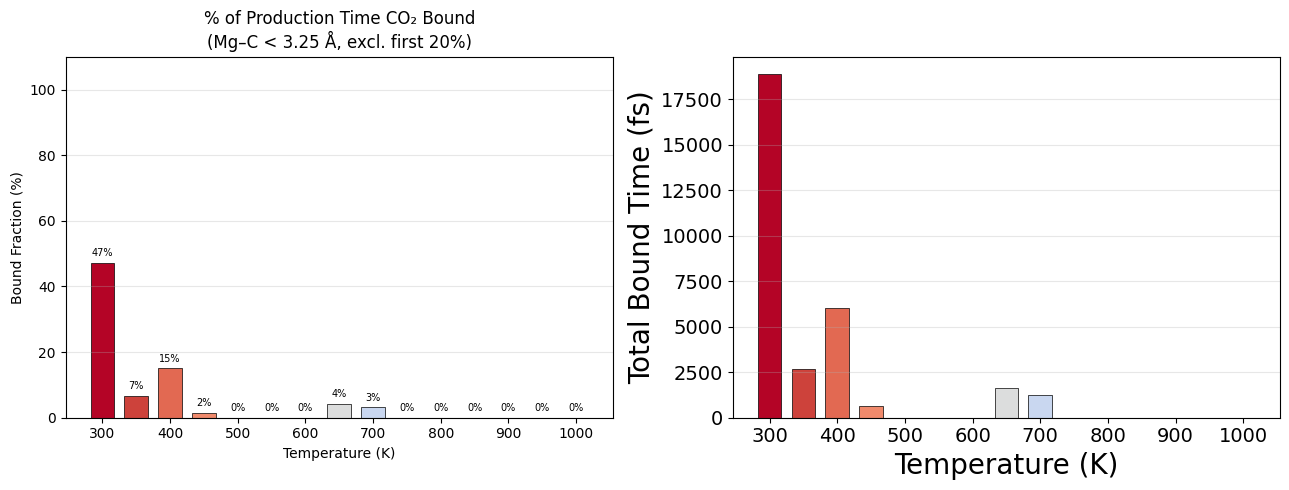

In [60]:
# -------------------------------------------------------
# Plot 5 — Box plot of "binding time" (Mg–C distance < threshold)
# -------------------------------------------------------
BINDING_THRESHOLD_A = 3.25   # Å — distance cutoff for "bound"
EQ_CUT_FRAC         = 0.20  # discard first 20% as equilibration

binding_times = {}   # T -> total fs spent bound (production window only)
bound_fracs   = {}   # T -> fraction of production frames that are bound

for T, fpath in zip(temperatures, traj_files):
    traj = Trajectory(fpath, "r")
    frames = list(traj)

    eq_cut = int(len(frames) * EQ_CUT_FRAC)
    prod_frames = frames[eq_cut:]

    bound_count = 0
    for atoms in prod_frames:
        co2_start = len(atoms) - 3
        c_indices = [j for j in range(co2_start, len(atoms)) if atoms[j].symbol == "C"]
        if not c_indices:
            continue
        c_idx = c_indices[0]
        mg_c_dist = atoms.get_distance(MG_IDX, c_idx, mic=True)
        if mg_c_dist < BINDING_THRESHOLD_A:
            bound_count += 1

    total_prod_fs   = len(prod_frames) * TIMESTEP_FS * TRAJ_EVERY
    bound_fs        = bound_count * TIMESTEP_FS * TRAJ_EVERY
    binding_times[T] = bound_fs
    bound_fracs[T]   = bound_count / len(prod_frames) if prod_frames else 0.0
    print(f"  {T} K: bound {bound_count}/{len(prod_frames)} frames "
          f"({bound_fracs[T]*100:.1f}%)  →  {bound_fs:.0f} / {total_prod_fs:.0f} fs")

# Box plot — one box per temperature showing bound time distribution
# Since we have one value per temperature (scalar), we instead do a bar + scatter
# For a true box plot you'd need multiple independent runs per T.
# Here we show bound fraction as a bar chart with the raw fs annotated.

sorted_T     = sorted(binding_times.keys())
frac_vals    = [bound_fracs[T] * 100 for T in sorted_T]   # percent
time_vals    = [binding_times[T] for T in sorted_T]        # fs

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: bound fraction bar chart ──
colors = plt.cm.coolwarm_r(np.linspace(0, 1, len(sorted_T)))
bars = ax1.bar(sorted_T, frac_vals, width=35, color=colors, edgecolor='k', linewidth=0.5)
ax1.set_xlabel("Temperature (K)")
ax1.set_ylabel("Bound Fraction (%)")
ax1.set_title(f"% of Production Time CO₂ Bound\n(Mg–C < {BINDING_THRESHOLD_A} Å, excl. first {int(EQ_CUT_FRAC*100)}%)")
ax1.set_ylim(0, 110)
ax1.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, frac_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f"{val:.0f}%", ha='center', va='bottom', fontsize=7)

# ── Right: bound time in fs ──
ax2.bar(sorted_T, time_vals, width=35, color=colors, edgecolor='k', linewidth=0.5)
ax2.set_xlabel("Temperature (K)", fontsize=20)
ax2.set_ylabel("Total Bound Time (fs)", fontsize=20)
#ax2.set_title(f"Total Production Time CO₂ Bound\n(Mg–C < {BINDING_THRESHOLD_A} Å)")
ax2.grid(True, alpha=0.3, axis='y')
ax2.tick_params(axis='both', labelsize=14)

plt.tight_layout()
#plt.savefig(f"binding_time_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png",
            #dpi=150, bbox_inches="tight")
plt.show()

  300 K: 1001 frames loaded & MSD calculated
  350 K: 1001 frames loaded & MSD calculated
  400 K: 1001 frames loaded & MSD calculated
  450 K: 1001 frames loaded & MSD calculated
  500 K: 1001 frames loaded & MSD calculated
  550 K: 1001 frames loaded & MSD calculated
  600 K: 1001 frames loaded & MSD calculated
  650 K: 1001 frames loaded & MSD calculated
  700 K: 1001 frames loaded & MSD calculated
  750 K: 1001 frames loaded & MSD calculated
  800 K: 1001 frames loaded & MSD calculated
  850 K: 1001 frames loaded & MSD calculated
  900 K: 1001 frames loaded & MSD calculated
  950 K: 1001 frames loaded & MSD calculated
  1000 K: 1001 frames loaded & MSD calculated


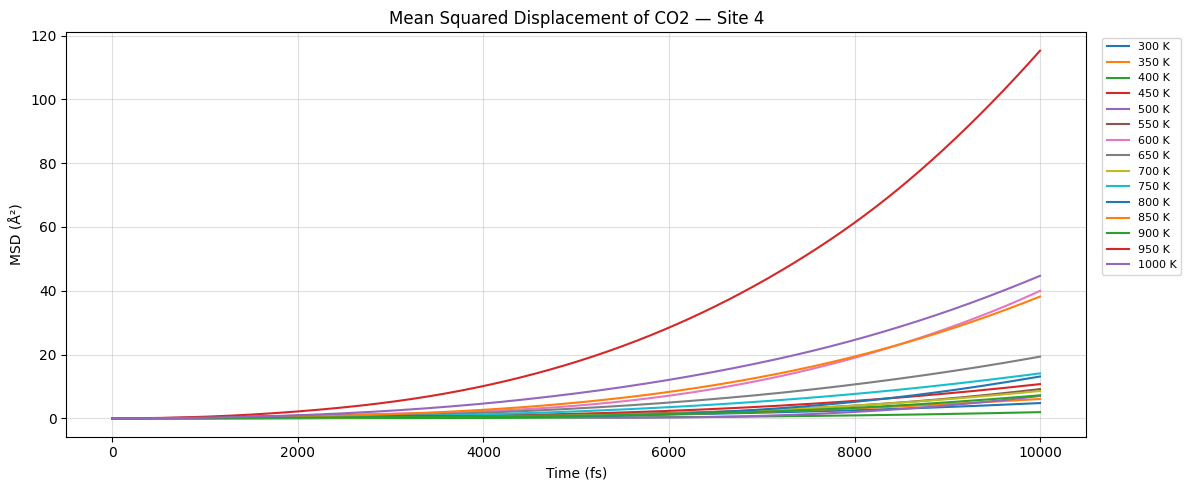

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from ase.io.trajectory import Trajectory
import glob
import re
from datetime import datetime

# -------------------------------------------------------
# CONFIG — edit these
# -------------------------------------------------------
TRAJ_FOLDER  = "/Users/christopherli/Documents/2026_Spring/cbe423/final-project/trajectories_2"
MG_IDX       = 4
TIMESTEP_FS  = 1.0
TRAJ_EVERY   = 10
E_MOF        = -1177.415309
E_CO2        = -22.596883

# Note: In your original snippet, E_mof_T and E_co2_T were used. 
# If they are constants, I'll use E_MOF and E_CO2.
# -------------------------------------------------------

traj_files = glob.glob(f"{TRAJ_FOLDER}/md_site4_*K_*.traj")

def extract_temp(fname):
    match = re.search(r'_(\d+)K_', fname)
    return int(match.group(1)) if match else 0

traj_files = sorted(traj_files, key=extract_temp)
temperatures = [extract_temp(f) for f in traj_files]

data = {}

for T, fpath in zip(temperatures, traj_files):
    traj = Trajectory(fpath, "r")

    times   = []
    mg_o_d1 = []
    mg_o_d2 = []
    e_bind  = []
    com_positions = [] # To store Center of Mass

    for i, atoms in enumerate(traj):
        time_fs = i * TIMESTEP_FS * TRAJ_EVERY
        
        # 1. Identify CO2 atoms
        co2_indices = list(range(len(atoms) - 3, len(atoms)))
        
        # 2. Get Center of Mass (Important: use get_positions with wrap=False for diffusion)
        # Note: This assumes your trajectory has unwrapped coordinates. 
        # If not, use atoms.get_center_of_mass(indices=co2_indices)
        com = atoms[co2_indices].get_center_of_mass()
        com_positions.append(com)

        # Mg-O distances
        o_indices = [j for j in co2_indices if atoms[j].symbol == "O"]
        dists = sorted([atoms.get_distance(MG_IDX, o_idx, mic=True) for o_idx in o_indices])

        times.append(time_fs)
        mg_o_d1.append(dists[0])
        mg_o_d2.append(dists[1])
        # Using the constant energy values defined in config
        e_bind.append(atoms.get_potential_energy() - E_MOF - E_CO2)

    # Calculate MSD: |r(t) - r(0)|^2
    com_positions = np.array(com_positions)
    displacements = com_positions - com_positions[0]
    sq_displacements = np.sum(displacements**2, axis=1)

    data[T] = {
        "times":   np.array(times),
        "mg_o_d1": np.array(mg_o_d1),
        "mg_o_d2": np.array(mg_o_d2),
        "e_bind":  np.array(e_bind),
        "msd":     sq_displacements,
    }
    print(f"  {T} K: {len(times)} frames loaded & MSD calculated")

# -------------------------------------------------------
# NEW Plot — Mean Squared Displacement (MSD) vs Time
# -------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))
for T, d in data.items():
    ax.plot(d["times"], d["msd"], lw=1.5, label=f"{T} K")

ax.set_xlabel("Time (fs)")
ax.set_ylabel("MSD (Å²)")
ax.set_title(f"Mean Squared Displacement of CO2 — Site {MG_IDX}")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f"msd_comparison_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png", dpi=150)
plt.show()

# -------------------------------------------------------
# (Your original Plot 1, 2, 3, and Summary Plot 4 follow here)
# -------------------------------------------------------

In [64]:
from ase.io import read
from ase.visualize import view

trajectory = read("/Users/christopherli/Documents/2026_Spring/cbe423/final-project/cbe423-final_project/trajectories_gui_corrected/md_sitegui_1000K_20260422_123025.traj", index=":")

view(trajectory)

<Popen: returncode: None args: ['/Users/christopherli/miniconda3/envs/cms/bi...>

In [20]:
atoms = read("mof_co2_initial.cif")
view(atoms)

<Popen: returncode: None args: ['/Users/christopherli/miniconda3/envs/cms/bi...>

Loaded 5001 frames
Energy spread: 1.0155 eV  (expect ~0.05–0.3 eV for NVT)
Energy range:  -1200.5984 to -1192.5782 eV

=== Boltzmann averages (NVT, T=300.0 K) ===
<r(Mg–C)>  = 2.937 ± 0.104 Å
<θ tilt>   = 53.1 ± 16.3 °

<r> reweighted to 200 K: nan Å
<r> reweighted to 400 K: nan Å

PMF minimum (binding distance): 2.940 Å
PMF well depth (affinity proxy): 0.188 eV


/var/folders/_z/4q19dfw93z98h599v771k7wr0000gn/T/ipykernel_24579/2022144241.py:83: RuntimeWarning: invalid value encountered in divide
  w /= w.sum()
/var/folders/_z/4q19dfw93z98h599v771k7wr0000gn/T/ipykernel_24579/2022144241.py:82: RuntimeWarning: overflow encountered in exp
  w  = np.exp(-E * (1/(kB*T_new) - 1/(kB*T_sim)))


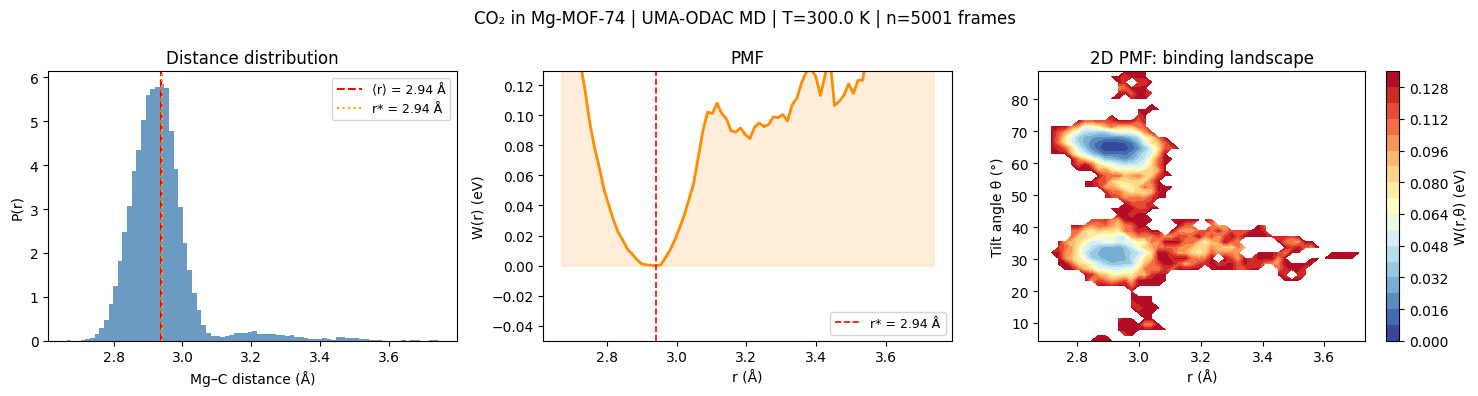

In [ ]:
from ase.io import read
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Load ───────────────────────────────────────────────────────────
frames = read("./trajectories_gui_corrected/md_sitegui_300K_20260420_143719.traj", index=":")
print(f"Loaded {len(frames)} frames")

# Pull energies — UMA/ODAC stores these in the traj automatically
energies = np.array([atoms.get_potential_energy() for atoms in frames])
T   = 300.0          # K — match your MD thermostat temperature
kBT = 8.617e-5 * T  # eV

print(f"Energy spread: {energies.std():.4f} eV  (expect ~0.05–0.3 eV for NVT)")
print(f"Energy range:  {energies.min():.4f} to {energies.max():.4f} eV")

# ── 2. Identify CO2 carbons robustly ─────────────────────────────────
def get_co2_carbons(atoms):
    """
    Returns indices of CO2 carbons: C atoms with exactly 2 O neighbors
    within 1.35 Å, using minimum image convention for PBC.
    """
    symbols   = np.array(atoms.get_chemical_symbols())
    c_indices = np.where(symbols == "C")[0]
    o_indices = np.where(symbols == "O")[0]
    co2_c = []
    for ci in c_indices:
        dists = atoms.get_distances(ci, o_indices, mic=True)
        if np.sum(dists < 1.35) == 2:
            co2_c.append(ci)
    return co2_c

# ── 3. Extract observables ────────────────────────────────────────────
r_vals     = []   # Mg–C(CO2) distance, Å
theta_vals = []   # CO2 tilt angle vs Mg–C vector, degrees
frame_idx  = []   # which frame each measurement came from

symbols_ref = np.array(frames[0].get_chemical_symbols())
mg_indices  = np.where(symbols_ref == "Mg")[0]
o_indices   = np.where(symbols_ref == "O")[0]

for fi, atoms in enumerate(frames):
    positions  = atoms.get_positions()
    co2_c_list = get_co2_carbons(atoms)

    for ci in co2_c_list:
        # PBC-safe Mg–C distance
        dists_mg = atoms.get_distances(ci, mg_indices, mic=True)
        r        = dists_mg.min()
        nearest_mg = mg_indices[np.argmin(dists_mg)]
        r_vals.append(r)
        frame_idx.append(fi)

        # Tilt angle
        dists_o   = atoms.get_distances(ci, o_indices, mic=True)
        bonded_o  = o_indices[np.argsort(dists_o)[:2]]
        co2_axis  = positions[bonded_o[1]] - positions[bonded_o[0]]
        mg_c_vec  = positions[ci] - positions[nearest_mg]
        cos_t     = np.dot(co2_axis, mg_c_vec) / (
                        np.linalg.norm(co2_axis) * np.linalg.norm(mg_c_vec))
        theta_vals.append(np.degrees(np.arccos(np.clip(abs(cos_t), 0, 1))))

r_vals     = np.array(r_vals)
theta_vals = np.array(theta_vals)
frame_idx  = np.array(frame_idx)

# ── 4. NVT Boltzmann averages (frames already thermally distributed) ──
r_mean    = np.mean(r_vals)
r_std     = np.std(r_vals)
r_mode    = r_vals[np.argmin(np.abs(r_vals - np.percentile(r_vals, 25)))]
theta_mean = np.mean(theta_vals)

print(f"\n=== Boltzmann averages (NVT, T={T} K) ===")
print(f"<r(Mg–C)>  = {r_mean:.3f} ± {r_std:.3f} Å")
print(f"<θ tilt>   = {theta_mean:.1f} ± {np.std(theta_vals):.1f} °")

# ── 5. Optional: reweight to different temperature ────────────────────
def reweight(values, frame_indices, energies, T_new, T_sim):
    """Reweight NVT trajectory from T_sim to T_new using MBAR-lite."""
    kB = 8.617e-5
    E  = energies[frame_indices]
    w  = np.exp(-E * (1/(kB*T_new) - 1/(kB*T_sim)))
    w /= w.sum()
    return np.average(values, weights=w), w

r_mean_400, _ = reweight(r_vals, frame_idx, energies, T_new=400, T_sim=T)
r_mean_200, _ = reweight(r_vals, frame_idx, energies, T_new=200, T_sim=T)
print(f"\n<r> reweighted to 200 K: {r_mean_200:.3f} Å")
print(f"<r> reweighted to 400 K: {r_mean_400:.3f} Å")

# ── 6. PMF ────────────────────────────────────────────────────────────
counts, edges = np.histogram(r_vals, bins=80, density=True)
r_centers     = 0.5 * (edges[:-1] + edges[1:])
safe_counts   = np.where(counts > 0, counts, np.nan)
pmf           = -kBT * np.log(safe_counts / np.nanmax(safe_counts))  # min = 0 eV

r_bind        = r_centers[np.nanargmin(pmf)]
pmf_depth     = np.nanmax(pmf[r_centers > r_bind + 0.5]) - np.nanmin(pmf)
print(f"\nPMF minimum (binding distance): {r_bind:.3f} Å")
print(f"PMF well depth (affinity proxy): {pmf_depth:.3f} eV")

# ── 7. 2D PMF: binding landscape ─────────────────────────────────────
H, xe, ye     = np.histogram2d(r_vals, theta_vals, bins=50, density=True)
H             = np.where(H > 0, H, np.nan)
pmf2d         = -kBT * np.log(H / np.nanmax(H))
pmf2d         = np.clip(pmf2d, 0, 5 * kBT)   # clip at 5 kBT for clean viz

# ── 8. Plot ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"CO₂ in Mg-MOF-74 | UMA-ODAC MD | T={T} K | n={len(frames)} frames")

axes[0].hist(r_vals, bins=80, density=True, color="steelblue", alpha=0.8, edgecolor="none")
axes[0].axvline(r_mean, color="red", lw=1.5, linestyle="--", label=f"⟨r⟩ = {r_mean:.2f} Å")
axes[0].axvline(r_bind, color="orange", lw=1.5, linestyle=":", label=f"r* = {r_bind:.2f} Å")
axes[0].set_xlabel("Mg–C distance (Å)"); axes[0].set_ylabel("P(r)")
axes[0].set_title("Distance distribution"); axes[0].legend(fontsize=9)

axes[1].plot(r_centers, pmf, color="darkorange", lw=2)
axes[1].axvline(r_bind, color="red", lw=1.2, linestyle="--", label=f"r* = {r_bind:.2f} Å")
axes[1].fill_between(r_centers, pmf, alpha=0.15, color="darkorange")
axes[1].set_xlabel("r (Å)"); axes[1].set_ylabel("W(r) (eV)")
axes[1].set_title("PMF"); axes[1].legend(fontsize=9)
axes[1].set_ylim(-0.05, 5*kBT)

xc = 0.5*(xe[:-1]+xe[1:]); yc = 0.5*(ye[:-1]+ye[1:])
cf = axes[2].contourf(xc, yc, pmf2d.T, levels=20, cmap="RdYlBu_r")
axes[2].set_xlabel("r (Å)"); axes[2].set_ylabel("Tilt angle θ (°)")
axes[2].set_title("2D PMF: binding landscape")
plt.colorbar(cf, ax=axes[2], label="W(r,θ) (eV)")

plt.tight_layout()
plt.savefig("co2_mof74_uma_pmf.png", dpi=150, bbox_inches="tight")
plt.show()